In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
import tensorflow as tf

import os
os.getcwd()

NUM_CORES = os.cpu_count()
print('CPU Cores:', NUM_CORES)
# Verify that TensorFlow is using the GPU
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

CPU Cores: 4
Num GPUs Available:  2


In [4]:
#Load Data into DataFrames
test = pd.read_csv(r'/kaggle/input/spaceship-titanic/test.csv', index_col = 0)
train = pd.read_csv(r'/kaggle/input/spaceship-titanic/train.csv', index_col = 0)
print(test.head())
print(train.head())
data = [train, test]

            HomePlanet CryoSleep  Cabin  Destination   Age    VIP  \
PassengerId                                                         
0013_01          Earth      True  G/3/S  TRAPPIST-1e  27.0  False   
0018_01          Earth     False  F/4/S  TRAPPIST-1e  19.0  False   
0019_01         Europa      True  C/0/S  55 Cancri e  31.0  False   
0021_01         Europa     False  C/1/S  TRAPPIST-1e  38.0  False   
0023_01          Earth     False  F/5/S  TRAPPIST-1e  20.0  False   

             RoomService  FoodCourt  ShoppingMall     Spa  VRDeck  \
PassengerId                                                         
0013_01              0.0        0.0           0.0     0.0     0.0   
0018_01              0.0        9.0           0.0  2823.0     0.0   
0019_01              0.0        0.0           0.0     0.0     0.0   
0021_01              0.0     6652.0           0.0   181.0   585.0   
0023_01             10.0        0.0         635.0     0.0     0.0   

                         Name  


In [5]:
#Data Cleaning
    
#Handle missing values
def missing_values(dataset):
    dataset['HomePlanet'] = dataset['HomePlanet'].fillna('Unknown')
    dataset['CryoSleep'] = dataset['CryoSleep'].fillna('Unknown')
    dataset['Cabin'] = dataset['Cabin'].fillna('U/0/U')
    dataset['Destination'] = dataset['Destination'].fillna('Unknown')
    dataset['Age'].fillna(dataset['Age'].mean(), inplace = True)
    dataset['VIP'] = dataset['VIP'].fillna('Unknown')
    dataset['RoomService'] = dataset['RoomService'].fillna(dataset['RoomService'].mean())
    dataset['FoodCourt'] = dataset['FoodCourt'].fillna(dataset['FoodCourt'].mean())
    dataset['ShoppingMall'] = dataset['ShoppingMall'].fillna(dataset['ShoppingMall'].mean())
    dataset['Spa'] = dataset['Spa'].fillna(dataset['Spa'].mean())
    dataset['VRDeck'] = dataset['VRDeck'].fillna(dataset['VRDeck'].mean())
        
    return dataset

train = missing_values(train)
test = missing_values(test)

#drop name column
train = train.drop(columns = ['Name'])
test = test.drop(columns = ['Name'])

print('train missing values:\n', train.isnull().sum())
print('test missing values:\n', test.isnull().sum())

train missing values:
 HomePlanet      0
CryoSleep       0
Cabin           0
Destination     0
Age             0
VIP             0
RoomService     0
FoodCourt       0
ShoppingMall    0
Spa             0
VRDeck          0
Transported     0
dtype: int64
test missing values:
 HomePlanet      0
CryoSleep       0
Cabin           0
Destination     0
Age             0
VIP             0
RoomService     0
FoodCourt       0
ShoppingMall    0
Spa             0
VRDeck          0
dtype: int64


<ipython-input-5-3cbd2d0ef18b>:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  dataset['Age'].fillna(dataset['Age'].mean(), inplace = True)


In [6]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split

# Data Preprocessing
num_cols = ['Age', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck', 'TotalSpent']
cat_cols = ['HomePlanet', 'CryoSleep', 'Destination', 'VIP']

def preprocess_data(df, num_cols, cat_cols):
    # Drop rows with missing values
    df.dropna(inplace=True)
    
    # Separate the cabin columns into 3 different columns
    df[['Deck', 'Roomnumber', 'Side']] = df['Cabin'].str.split('/', expand=True)
    
    # Convert Roomnumber to numerical
    df['Roomnumber'] = pd.to_numeric(df['Roomnumber'], errors='coerce')
    
    # Add a combined spent column to gauge how much a passenger spent
    df['TotalSpent'] = df['RoomService'] + df['FoodCourt'] + df['ShoppingMall'] + df['Spa'] + df['VRDeck']
    
    # Standardize numerical columns
    scaler = StandardScaler()
    scaled_cols = scaler.fit_transform(df[num_cols + ['Roomnumber']])
    scaled_df = pd.DataFrame(scaled_cols, columns=num_cols + ['Roomnumber'], index=df.index)
    
    # Convert categorical columns to strings
    for col in cat_cols + ['Deck', 'Side']:
        df[col] = df[col].astype(str)
    
    # One-hot encode categorical columns including Deck and Side
    encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
    encoded_cols = encoder.fit_transform(df[cat_cols + ['Deck', 'Side']])
    encoded_df = pd.DataFrame(encoded_cols, columns=encoder.get_feature_names_out(cat_cols + ['Deck', 'Side']), index=df.index)
    
    # Concatenate the scaled and encoded columns with the original DataFrame
    df = pd.concat([df, scaled_df, encoded_df], axis=1)
    
    # Drop old columns
    df.drop(columns=num_cols + cat_cols + ['Deck', 'Side', 'Cabin'], inplace=True)
    
    return df

p_train = preprocess_data(train, num_cols, cat_cols)
print(f'train_shape: {p_train.shape}')

p_test = preprocess_data(test, num_cols, cat_cols)
print(f'test_shape: {p_test.shape}')

#create train test split
X = p_train.drop(columns=['Transported'])
y = p_train['Transported']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 117)

train_shape: (8693, 29)
test_shape: (4277, 28)


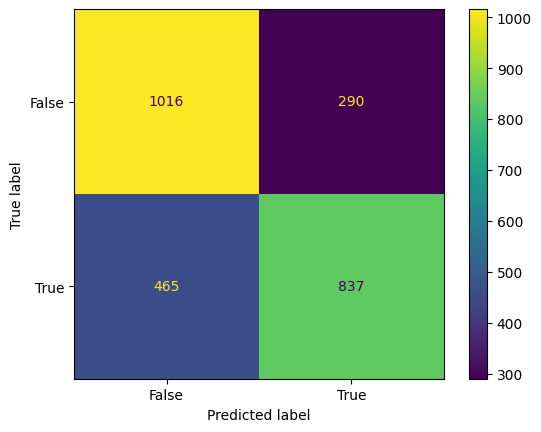

Best parameters found:  {'var_smoothing': 1e-06}
Best cross-validation score:  0.7137207242243541


In [5]:
#Bayes Classifier
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score



NB = GaussianNB()

param_grid = {
    'var_smoothing': [1e-9, 1e-8, 1e-7, 1e-6, 1e-5, 1e-4, 1e-3, 1e-2, 1e-1]
}

GS = GridSearchCV(NB, param_grid, cv = 10, scoring = 'accuracy', n_jobs = NUM_CORES)

GS.fit(X_train, y_train)

Best_NB = GS.best_estimator_


y_pred = Best_NB.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=Best_NB.classes_)
disp.plot()
plt.show()

print("Best parameters found: ", GS.best_params_)
print("Best cross-validation score: ", GS.best_score_)


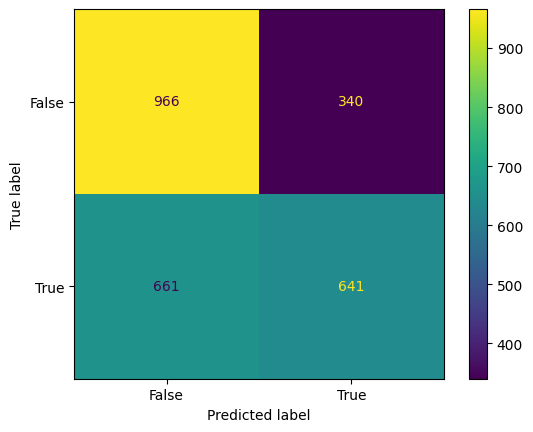

Best parameters found:  {'n_neighbors': 8}
Best cross-validation score:  0.6121648409817648


In [6]:
#kNN Classifier
from sklearn.neighbors import KNeighborsClassifier

kNN = KNeighborsClassifier()
param_grid = {
    'n_neighbors': range(1, 1000)
}

GS = GridSearchCV(kNN, param_grid, cv = 10, scoring = 'accuracy', n_jobs = NUM_CORES) #use all cores so its a bit faster
GS.fit(X_train, y_train)
Best_kNN = GS.best_estimator_
y_pred = Best_kNN.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=Best_kNN.classes_)
disp.plot()
plt.show()

print("Best parameters found: ", GS.best_params_)
print("Best cross-validation score: ", GS.best_score_)

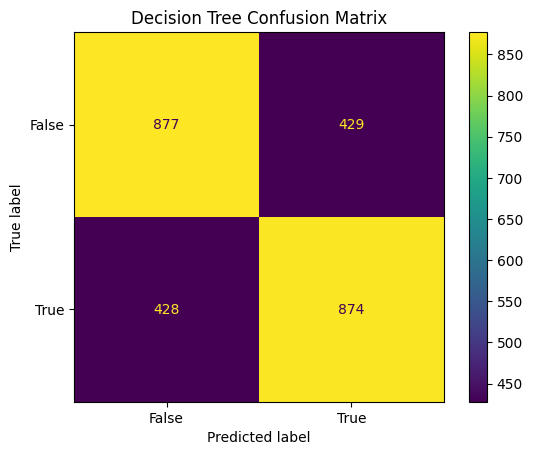

Decision Tree Accuracy: 0.6713957055214724


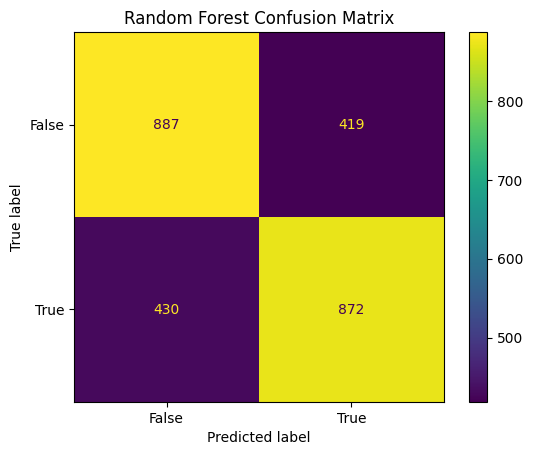

Random Forest Accuracy: 0.6744631901840491


In [7]:
#Decision Tree Classifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

DT = DecisionTreeClassifier()

DT.fit(X_train, y_train)
y_pred = DT.predict(X_test)
cm = confusion_matrix(y_test, y_pred)  
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=DT.classes_)
disp.plot()
plt.title("Decision Tree Confusion Matrix")
plt.show()
accuracy_dt = accuracy_score(y_test, y_pred)
print(f"Decision Tree Accuracy: {accuracy_dt}")


#Random Forest Classifier
RF = RandomForestClassifier()
RF.fit(X_train, y_train)
y_pred = RF.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=RF.classes_)
disp.plot()
plt.title("Random Forest Confusion Matrix")
plt.show()
accuracy_rf = accuracy_score(y_test, y_pred)
print(f"Random Forest Accuracy: {accuracy_rf}")


In [8]:
#Use best model so far to predict test set for submission csv
y_test_pred = Best_NB.predict(p_test)
submission = pd.DataFrame({'PassengerId': test.index, 'Transported': y_test_pred})
submission.to_csv('submission.csv', index=False)

In [7]:
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from keras_tuner import HyperModel
from keras_tuner.tuners import Hyperband

class spacetitanic(HyperModel):
    def build(self, hp):
        model = keras.Sequential()
        model.add(layers.InputLayer(shape=(X_train.shape[1],)))
        model.add(layers.BatchNormalization())
        
        for i in range(hp.Int('num_layers', 1, 50)):
            units = hp.Int('units_' + str(i), min_value = 52, max_value = 2048, step = 256)
            activation = hp.Choice('activation_' + str(i), ['relu', 'leaky_relu'])
            
            kernel_regularizer = regularizers.l2(hp.Float('l2_regularization_' + str(i),
                                                          min_value=1e-7,
                                                          max_value=1e-1,
                                                          sampling='log'))
            model.add(layers.Dense(units = units, activation = activation, kernel_regularizer = kernel_regularizer))
            model.add(layers.BatchNormalization())
            model.add(layers.Dropout(hp.Float('dropout_' + str(i),
                                          min_value = 0,
                                          max_value = 0.5,
                                          step = 0.1)))
        model.add(layers.Dense(1, activation = 'sigmoid'))
        
        model.compile(optimizer = keras.optimizers.Adam(hp.Float('learning_rate',
                                                                min_value = 1e-4,
                                                                max_value = 1e-2,
                                                                sampling = 'LOG')),
                      loss = 'binary_crossentropy',
                      metrics = ['accuracy'])
        return model
    
tuner = Hyperband(
    spacetitanic(),
    objective = 'val_accuracy',
    max_epochs = 1000,
    factor = 3,
    directory = 'Hyperband_NN'
)
        
    

Reloading Tuner from Hyperband_NN/untitled_project/tuner0.json


In [8]:
PATIENCE = 25
EPOCHS = 1000
MIN_DELTA = 1e-3

tuner.search(X_train, y_train,
             validation_data = (X_test, y_test),
             epochs = EPOCHS,
             callbacks = [keras.callbacks.EarlyStopping(
                    monitor = 'val_accuracy',
                    patience = PATIENCE,
                    min_delta = MIN_DELTA
             )])

Trial 80 Complete [00h 00m 42s]
val_accuracy: 0.5007668733596802

Best val_accuracy So Far: 0.7277607321739197
Total elapsed time: 01h 53m 37s

Search: Running Trial #81

Value             |Best Value So Far |Hyperparameter
42                |2                 |num_layers
1076              |564               |units_0
relu              |leaky_relu        |activation_0
9.9974e-07        |3.1676e-05        |l2_regularization_0
0.2               |0                 |dropout_0
0.0013507         |0.003328          |learning_rate
1332              |52                |units_1
relu              |relu              |activation_1
3.7503e-06        |0.00033689        |l2_regularization_1
0.3               |0                 |dropout_1
564               |1588              |units_2
relu              |leaky_relu        |activation_2
4.7617e-07        |0.014344          |l2_regularization_2
0                 |0                 |dropout_2
1844              |820               |units_3
relu              |l

Traceback (most recent call last):
  File "/usr/local/lib/python3.10/dist-packages/keras_tuner/src/engine/base_tuner.py", line 274, in _try_run_and_update_trial
    self._run_and_update_trial(trial, *fit_args, **fit_kwargs)
  File "/usr/local/lib/python3.10/dist-packages/keras_tuner/src/engine/base_tuner.py", line 239, in _run_and_update_trial
    results = self.run_trial(trial, *fit_args, **fit_kwargs)
  File "/usr/local/lib/python3.10/dist-packages/keras_tuner/src/tuners/hyperband.py", line 427, in run_trial
    return super().run_trial(trial, *fit_args, **fit_kwargs)
  File "/usr/local/lib/python3.10/dist-packages/keras_tuner/src/engine/tuner.py", line 314, in run_trial
    obj_value = self._build_and_fit_model(trial, *args, **copied_kwargs)
  File "/usr/local/lib/python3.10/dist-packages/keras_tuner/src/engine/tuner.py", line 233, in _build_and_fit_model
    results = self.hypermodel.fit(hp, model, *args, **kwargs)
  File "/usr/local/lib/python3.10/dist-packages/keras_tuner/src/eng

RuntimeError: Disable slist on flush dest failure failed (file write failed: time = Sun Mar  2 20:54:11 2025
, filename = 'Hyperband_NN/untitled_project/trial_0080/checkpoint.weights.h5', file descriptor = 96, errno = 28, error message = 'No space left on device', buf = 0x5c5e3c9bc908, total write size = 5208, bytes this sub-write = 5208, bytes actually written = 18446744073709551615, offset = 0)

Exception ignored in: 'h5py._objects.ObjectID.__dealloc__'
Traceback (most recent call last):
  File "h5py/_objects.pyx", line 201, in h5py._objects.ObjectID.__dealloc__
RuntimeError: Disable slist on flush dest failure failed (file write failed: time = Sun Mar  2 20:54:11 2025
, filename = 'Hyperband_NN/untitled_project/trial_0080/checkpoint.weights.h5', file descriptor = 96, errno = 28, error message = 'No space left on device', buf = 0x5c5e3c9bc908, total write size = 5208, bytes this sub-write = 5208, bytes actually written = 18446744073709551615, offset = 0)


ResourceExhaustedError: Hyperband_NN/untitled_project/trial_0080/trial.json; No space left on device

In [1]:
Best_Model = tuner.get_best_models(num_models = 1)[0]

preds = Best_Model.predict(p_test)
predicted_classes = (preds > 0.5).flatten()

submission = pd.DataFrame({'PassengerId': test.index, 'Transported': predicted_classes})
submission.to_csv('submission.csv', index=False)  

NameError: name 'tuner' is not defined